# Cityflo Mobility Analysis — Reference Data Audit

This notebook validates the datasets, assumptions, and parameters used by the downstream mobility analysis pipeline.

Goals:

- Understand GPS data structure
- Validate stop reference data
- Validate trip schedules and route structures
- Quantify data quality issues
- Measure the impact of cleaning decisions
- Establish clean reference datasets for downstream analysis

**Note:** GPS datasets are multi-GB. Use lazy loading, streaming, and chunked processing wherever possible.

**Current status:** Stops audit and trips audit completed. GPS cleaning and preprocessing is handled in a separate notebook.

## Section 0 — Setup

Load libraries, define paths, and configure notebook settings.

In [23]:
# Core
from pathlib import Path
from collections import Counter, defaultdict
import json
import re
import os

import numpy as np
import pandas as pd
import polars as pl

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Spatial
from sklearn.neighbors import BallTree
from haversine import haversine, Unit

# Paths
RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../outputs/figures/eda")
GPS_FILES = [
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756",
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2",
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3",
]

PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

STOPS_FILE = RAW / "stops.csv"
STOP_COORDS_FILE = RAW / "bus_stops_coords.csv"
TRIPS_FILE = RAW / "trips.csv"

MUMBAI_BBOX = {
    "lat_min": 18.8894,
    "lat_max": 19.3274,
    "lng_min": 72.7692,
    "lng_max": 73.1165,
}

print("Setup complete")

print("\nReference files —")
print(f"stops.csv            : {STOPS_FILE.exists()}")
print(f"bus_stops_coords.csv : {STOP_COORDS_FILE.exists()}")
print(f"trips.csv            : {TRIPS_FILE.exists()}")

print("\nGPS files —")
for f in GPS_FILES:
    size_gb = f.stat().st_size / 1e9 if f.exists() else 0
    print(f"{f.name[:50]:50s} {size_gb:6.2f} GB")

print("\nOutput folders —")
print(FIGURES)
print(PROCESSED)

Setup complete

Reference files —
stops.csv            : True
bus_stops_coords.csv : True
trips.csv            : True

GPS files —
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756   6.44 GB
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756   6.44 GB
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756   5.45 GB

Output folders —
../outputs/figures/eda
../data/processed


## Section 1 — GPS Schema Validation

Verify that all GPS files share the same layout before defining a schema.

In [2]:
from collections import Counter

column_count_counter = Counter()

print("FILENAME(SIZE) WITH COLUMNN COUNT DISTRIBUTION (FIRST 10K ROWS)")
for gps_file in GPS_FILES:
    print()
    print(f"{gps_file.name} " f"({gps_file.stat().st_size / 1e9:.2f} GB)")

    counts = []

    with open(gps_file, "r", errors="ignore") as f:

        for i, line in enumerate(f):

            counts.append(len(line.rstrip("\n").split(",")))

            if i >= 10000:
                break

    c = Counter(counts)

    print("Column count distribution (first 10k rows):")

    for k, v in sorted(c.items()):
        print(f"  {k:2d} columns : {v:,}")

    column_count_counter.update(counts)

print("\nGLOBAL SUMMARY —")

for k, v in sorted(column_count_counter.items()):
    print(f"{k:2d} columns : {v:,}")

FILENAME(SIZE) WITH COLUMNN COUNT DISTRIBUTION (FIRST 10K ROWS)

before_2022-10-22_698096e5f4994518a37a0b9c59bb9756 (6.44 GB)
Column count distribution (first 10k rows):
  14 columns : 10,001

before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2 (6.44 GB)
Column count distribution (first 10k rows):
  14 columns : 10,001

before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3 (5.45 GB)
Column count distribution (first 10k rows):
  14 columns : 10,001

GLOBAL SUMMARY —
14 columns : 30,003


In [28]:
stops = pd.read_csv(STOPS_FILE)

print("Length of stops: ", len(stops))
STUDY_START = "2021-09-01"
STUDY_END = "2022-10-22"
hours = pd.date_range(STUDY_START, STUDY_END, freq="h")

print(len(hours))


Length of stops:  6115
9985


## Section 2 — GPS Record Inspection

Inspect a small sample of GPS records to understand column meanings and identify obvious data quality issues before defining a schema.

In [56]:
# RAW RECORD INSPECTION
gps_file = GPS_FILES[0]

# First few rows
with open(gps_file, "r", errors="ignore") as f:

    for i in range(5):

        row = next(f).rstrip("\n")

        parts = row.split(",")

        print("-" * 100)
        print(f"ROW {i}")
        print("-" * 100)

        for idx, value in enumerate(parts, start=1):
            print(f"{idx:02d}: {repr(value)}")
        print()

# Deep row checks
print("-" * 100)
print("DEEP ROW VALIDATION:")
print("-" * 100)
sample_positions = [
    100_000,
    500_000,
    1_000_000,
    5_000_000,
]

for target in sample_positions:

    with open(gps_file, "r", errors="ignore") as f:

        for i, line in enumerate(f):

            if i == target:

                cols = len(line.rstrip("\n").split(","))

                print(f"row {target:,} — " f"{cols} columns")

                break

----------------------------------------------------------------------------------------------------
ROW 0
----------------------------------------------------------------------------------------------------
01: '278563236'
02: '19.2732055'
03: '72.9614731'
04: '2021-09-01 18:30:00.100189+00'
05: '1527'
06: '2021-09-01 18:29:59.759+00'
07: '54.813'
08: '62'
09: '1'
10: ''
11: '4'
12: '0'
13: ''
14: '1'

----------------------------------------------------------------------------------------------------
ROW 1
----------------------------------------------------------------------------------------------------
01: '278563237'
02: '19.1749566'
03: '73.0254066'
04: '2021-09-01 18:30:00.150596+00'
05: '656'
06: '2021-09-01 18:29:59.743+00'
07: '3.9'
08: '22'
09: '1'
10: ''
11: '4'
12: '0'
13: '2'
14: '1'

----------------------------------------------------------------------------------------------------
ROW 2
----------------------------------------------------------------------------------

### Observations

- GPS records contain 14 fields.
- Columns 4 and 6 appear to be ingestion and event timestamps.
- Column 7 contains reported speed and includes obvious sentinel values (>600 km/h).
- Column 8 appears to be heading/bearing.
- Column 9 appears to be a source identifier.
- Several remaining columns require profiling before assigning meanings.

These assumptions will be validated using larger samples in the next section.

## Section 3 — Stops Audit

Assess stop coverage, coordinate quality, and repair requirements before using stops for route reconstruction.

In [60]:
stops = pd.read_csv(STOPS_FILE)

print("STOPS AUDIT")

print(f"Rows                    : {len(stops):,}")
print(f"Columns                 : {len(stops.columns)}")
print(f"Unique stop_ids         : {stops['stop_id'].nunique():,}")
print(f"Duplicate stop_ids      : {stops['stop_id'].duplicated().sum():,}")

missing_coords = stops["lat"].isna() | stops["lng"].isna()

print("\nCoordinate Coverage —")
print(f"Stops with coords       : {(~missing_coords).sum():,}")
print(f"Stops missing coords    : {missing_coords.sum():,}")
print(f"Coverage               : {100*(~missing_coords).mean():.2f}%")

valid = stops.dropna(subset=["lat", "lng"])

print("\nCoordinate Range —")
print(f"Lat range              : {valid['lat'].min():.6f} → {valid['lat'].max():.6f}")
print(f"Lng range              : {valid['lng'].min():.6f} → {valid['lng'].max():.6f}")

outside = valid[
    (valid["lat"] < MUMBAI_BBOX["lat_min"])
    | (valid["lat"] > MUMBAI_BBOX["lat_max"])
    | (valid["lng"] < MUMBAI_BBOX["lng_min"])
    | (valid["lng"] > MUMBAI_BBOX["lng_max"])
]

print(f"Outside Mumbai bbox    : {len(outside):,}")

print("\nCategory Distribution —")
print(stops["stop_category"].value_counts(dropna=False))

print("\nDuplicate stop names —")
dup_names = stops["stop_name"].astype(str).str.strip().str.lower().duplicated().sum()

print(f"Duplicate names        : {dup_names:,}")

STOPS AUDIT
Rows                    : 6,115
Columns                 : 5
Unique stop_ids         : 6,115
Duplicate stop_ids      : 0

Coordinate Coverage —
Stops with coords       : 6,115
Stops missing coords    : 0
Coverage               : 100.00%

Coordinate Range —
Lat range              : 0.000000 → 72.212300
Lng range              : 0.000000 → 119.417900
Outside Mumbai bbox    : 1,699

Category Distribution —
stop_category
Morning    4450
Evening    1665
Name: count, dtype: int64

Duplicate stop names —
Duplicate names        : 3,159


In [63]:
# INSPECT SUSPICIOUS COORDINATES
outside = valid[
    (valid["lat"] < MUMBAI_BBOX["lat_min"])
    | (valid["lat"] > MUMBAI_BBOX["lat_max"])
    | (valid["lng"] < MUMBAI_BBOX["lng_min"])
    | (valid["lng"] > MUMBAI_BBOX["lng_max"])
]

print(f"Outside Mumbai bbox: {len(outside):,}")

display(outside[["stop_id", "stop_name", "lat", "lng", "stop_category"]].head(50))

invalid_zero = stops[(stops["lat"] == 0) & (stops["lng"] == 0)]

invalid_name = stops[
    stops["stop_name"].str.lower().str.contains("dummy|test", na=False)
]

outside_india = stops[~(stops["lat"].between(6, 38)) | ~(stops["lng"].between(68, 98))]

print("\nInvalid coordinate summary —")
print(f"Zero coordinates     : {len(invalid_zero):,}")
print(f"Dummy/Test stops     : {len(invalid_name):,}")
print(f"Outside India bounds : {len(outside_india):,}")

display(outside_india[["stop_id", "stop_name", "lat", "lng"]].head(20))

Outside Mumbai bbox: 1,699


,stop_id,stop_name,lat,lng,stop_category
345,366,Katraj Junction (Jspm),18.451060,73.857521,Morning
346,367,NIBM,18.477383,73.901562,Morning
347,368,Nibm Square - Jyoti Hotel,18.478122,73.890158,Morning
348,369,Warje Popular Nagar,18.484692,73.798480,Morning
349,370,Rahul Park (Atul Nagar),18.485740,73.795563,Morning
350,371,Kakade City,18.487305,73.810660,Morning
351,372,Kothrud Depot-ICICI Bank,18.507980,73.795841,Morning
352,373,Phase 1 - Mindtree,18.593964,73.732093,Morning
353,374,Dahanukar Colony Circle,18.505627,73.813999,Morning
354,375,Shashtri Nagar Police Station,18.506593,73.802456,Morning



Invalid coordinate summary —
Zero coordinates     : 90
Dummy/Test stops     : 6
Outside India bounds : 112


,stop_id,stop_name,lat,lng
1261,2012,"Oberoi Woods, Goregaon",19.170500,67.864570
1292,2052,Test stop,36.778300,119.417900
1293,2053,Apna Nagar,1.000000,1.111000
1294,2054,Anand Nagar,1.100000,1.200000
1295,2055,Vasai Nagar,1.200000,1.120000
1296,2056,Sopara Nagar,1.112000,2.120000
1297,2057,Prabhat Nagar,1.111000,2.222000
1298,2058,Dummy,72.212300,69.123000
1317,2079,ICICI Bank,1.000000,1.100000
2246,8756,Chedda Nagar Signal,19.063713,19.063713


### Findings

- `stops.csv` contains 6,115 unique stops with complete coordinate coverage.
- The catalog is not Mumbai-only and includes stops from Pune, Virar, Palghar, and other operating regions.
- 112 stops contain clearly invalid coordinates, including `(0,0)`, test records, and corrupted locations.
- Stop names are not unique; all joins should use `stop_id`.
- A separate repair file appears exists for correcting invalid stop coordinates.

In [66]:
# BUS_STOPS_COORDS AUDIT
coords = pd.read_csv(STOP_COORDS_FILE)

print("BUS_STOPS_COORDS AUDIT —")

print(f"Rows                 : {len(coords):,}")
print(f"Columns              : {len(coords.columns)}")

print("\nColumns:")
for c in coords.columns:
    print(c)

print("\nDtypes:")
print(coords.dtypes)

print("\nNull counts:")
print(coords.isna().sum())

print("\nFirst rows:")
display(coords.head())

print("\nLast rows:")
display(coords.tail())

BUS_STOPS_COORDS AUDIT —
Rows                 : 90
Columns              : 8

Columns:
stop_id
stop_name
latitude
longitude
notes
Unnamed: 5
Unnamed: 6
Unnamed: 7

Dtypes:
stop_id         int64
stop_name      object
latitude      float64
longitude     float64
notes          object
Unnamed: 5    float64
Unnamed: 6    float64
Unnamed: 7    float64
dtype: object

Null counts:
stop_id        0
stop_name      0
latitude       0
longitude      0
notes          0
Unnamed: 5    90
Unnamed: 6    90
Unnamed: 7    90
dtype: int64

First rows:


,stop_id,stop_name,latitude,longitude,notes,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,16947,Bhayandar Pada,19.28333,72.95230,Mumbai - Bhayandar area,NaN,NaN,NaN
1,17163,Cotton Green,18.97990,72.83750,Mumbai - Cotton Green station area,NaN,NaN,NaN
2,17180,Shivaji Nagar (1),19.06616,72.92776,Pune - Shivaji Nagar,NaN,NaN,NaN
3,17181,Sancheti Bridge (1),18.53500,73.84900,Pune - Sancheti area,NaN,NaN,NaN
4,17182,Sangamwadi (1),18.53430,73.86123,Pune - Sangamwadi,NaN,NaN,NaN



Last rows:


,stop_id,stop_name,latitude,longitude,notes,Unnamed: 5,Unnamed: 6,Unnamed: 7
85,17353,Seasons Mall (2),18.517400,73.926000,Pune - Seasons Mall Hadapsar,NaN,NaN,NaN
86,17354,Bhaji Mandai (2),18.519600,73.857400,Pune - Bhaji Mandai Shivajinagar,NaN,NaN,NaN
87,17356,Akashwani (2),19.196332,72.811053,Pune - Akashwani (AIR) Shivajinagar,NaN,NaN,NaN
88,17421,Bisleri Junction,19.113170,72.855440,Pune - Bisleri Junction Viman Nagar,NaN,NaN,NaN
89,17970,Pratap Nagar,19.140810,72.856730,Pune - Pratap Nagar,NaN,NaN,NaN


### Findings

`bus_stops_coords.csv` contains 90 stop records with valid coordinates.

Observations:

- Rows closely match the number of placeholder coordinates found in `stops.csv`.
- Records are keyed by `stop_id`.
- The file appears to be a coordinate repair dataset rather than an independent stop catalog.
- Some metadata inconsistencies exist, so repairs should be validated before use.

Next step: measure how many invalid stops can actually be repaired.

In [67]:
# DOES bus_stops_coords.csv ACTUALLY REPAIR THE BAD STOPS?
invalid_stops = stops[
    ((stops["lat"] == 0) & (stops["lng"] == 0))
    | (~stops["lat"].between(6, 38))
    | (~stops["lng"].between(68, 98))
].copy()

print(f"Potentially invalid stops: {len(invalid_stops):,}")

repair_ids = set(coords["stop_id"])
invalid_ids = set(invalid_stops["stop_id"])

overlap = invalid_ids & repair_ids

print("\nRepair coverage —")
print(f"Invalid stops                : {len(invalid_ids):,}")
print(f"Repair records               : {len(repair_ids):,}")
print(f"Repairable invalid stops     : {len(overlap):,}")
print(f"Coverage                     : {100*len(overlap)/len(invalid_ids):.2f}%")

print("\nInvalid stops NOT in repair file:")

remaining = invalid_stops[~invalid_stops["stop_id"].isin(overlap)]

display(remaining[["stop_id", "stop_name", "lat", "lng"]].head(50))

Potentially invalid stops: 112

Repair coverage —
Invalid stops                : 112
Repair records               : 90
Repairable invalid stops     : 90
Coverage                     : 80.36%

Invalid stops NOT in repair file:


,stop_id,stop_name,lat,lng
1261,2012,"Oberoi Woods, Goregaon",19.170500,67.864570
1292,2052,Test stop,36.778300,119.417900
1293,2053,Apna Nagar,1.000000,1.111000
1294,2054,Anand Nagar,1.100000,1.200000
1295,2055,Vasai Nagar,1.200000,1.120000
1296,2056,Sopara Nagar,1.112000,2.120000
1297,2057,Prabhat Nagar,1.111000,2.222000
1298,2058,Dummy,72.212300,69.123000
1317,2079,ICICI Bank,1.000000,1.100000
2246,8756,Chedda Nagar Signal,19.063713,19.063713


### Findings

- 112 invalid stops were identified.
- 90 of them are covered by the repair file.
- Repair coverage is approximately 80%.
- The remaining invalid records include test stops, placeholder coordinates, and corrupted locations.
- These unrepaired stops require exclusion or manual review.

In [ ]:
# ARE THE REMAINING INVALID STOPS USED IN TRIPS?
import ast

invalid_remaining_ids = set(remaining["stop_id"])

trip_stop_ids = set()

for route in pd.read_csv(TRIPS_FILE, usecols=["trip_route"])["trip_route"]:
    matches = re.findall(r"\((\d+),", str(route))
    trip_stop_ids.update(map(int, matches))

invalid_used = invalid_remaining_ids & trip_stop_ids

print("Remaining invalid stops —")
print(f"Invalid stop IDs           : {len(invalid_remaining_ids)}")
print(f"Referenced in trips.csv    : {len(invalid_used)}")

if invalid_used:
    print("\nUsed invalid stops:")
    display(
        remaining[remaining["stop_id"].isin(invalid_used)][
            ["stop_id", "stop_name", "lat", "lng"]
        ].sort_values("stop_id")
    )
else:
    print("\nExcellent: none of the remaining invalid stops are used.")

Remaining invalid stops —
Invalid stop IDs           : 22
Referenced in trips.csv    : 9

Used invalid stops:


,stop_id,stop_name,lat,lng
1294,2054,Anand Nagar,1.100000,1.200000
3385,11198,Chedda Nagar Signal Tata Projects,19.063713,19.063713
3498,11566,Chedda Nagar Signal TATA Projects,19.063713,19.063713
3635,12007,Chedda Nagar Signal ISEC,19.063713,19.063713
3910,12628,Chedda Nagar Signal ISEC,19.063713,19.063713
3949,12706,Chedda Nagar Signal ISEC,19.063713,19.063713
4280,13488,Kharghar Railway station sub-way DFPCL,19.028576,3.060486
4291,13499,Kharghar Railway station sub- DFPCL,19.028576,3.060486
5597,17002,Airoli Axis Bank,19.147947,0.000000


In [69]:
# BUILD AND SAVE STOPS_CLEAN
repair = coords.rename(
    columns={
        "latitude": "lat_fix",
        "longitude": "lng_fix",
    }
)

stops_clean = stops.merge(
    repair[["stop_id", "lat_fix", "lng_fix"]],
    on="stop_id",
    how="left",
)

invalid_mask = (
    (stops_clean["lat"] == 0)
    | (stops_clean["lng"] == 0)
    | (stops_clean["lat"] < 6)
    | (stops_clean["lat"] > 38)
    | (stops_clean["lng"] < 68)
    | (stops_clean["lng"] > 98)
)

print("Invalid before repair:", invalid_mask.sum())

repairable = invalid_mask & stops_clean["lat_fix"].notna()

stops_clean.loc[repairable, "lat"] = stops_clean.loc[repairable, "lat_fix"]

stops_clean.loc[repairable, "lng"] = stops_clean.loc[repairable, "lng_fix"]

stops_clean.drop(
    columns=["lat_fix", "lng_fix"],
    inplace=True,
)

remaining_invalid = (
    (stops_clean["lat"] == 0)
    | (stops_clean["lng"] == 0)
    | (stops_clean["lat"] < 6)
    | (stops_clean["lat"] > 38)
    | (stops_clean["lng"] < 68)
    | (stops_clean["lng"] > 98)
)

print("Remaining invalid:", remaining_invalid.sum())

OUT_STOPS = PROCESSED / "stops_clean.csv"

stops_clean.to_csv(
    OUT_STOPS,
    index=False,
)

print("Saved:", OUT_STOPS)
print("Rows :", len(stops_clean))

Invalid before repair: 112
Remaining invalid: 22
Saved: ../data/processed/stops_clean.csv
Rows : 6115


In [129]:
corrected = pd.read_csv(RAW / "corrected_9.csv")
stops_clean = pd.read_csv(PROCESSED / "stops_clean.csv")

cmp = stops_clean[["stop_id", "lat", "lng"]].merge(
    corrected[["stop_id", "lat", "lng"]],
    on="stop_id",
    suffixes=("_old", "_new"),
    how="inner",
)

changed = cmp[
    (cmp["lat_old"].round(8) != cmp["lat_new"].round(8))
    | (cmp["lng_old"].round(8) != cmp["lng_new"].round(8))
]

print("Changed records:", len(changed))

display(changed.sort_values("stop_id"))

Changed records: 9


,stop_id,lat_old,lng_old,lat_new,lng_new
1294,2054,1.100000,1.200000,19.141486,72.861165
3385,11198,19.063713,19.063713,19.068649,72.904322
3498,11566,19.063713,19.063713,19.023436,72.904322
3635,12007,19.063713,19.063713,19.070806,72.907323
3910,12628,19.063713,19.063713,19.070806,72.907328
3949,12706,19.063713,19.063713,19.070806,72.907328
4280,13488,19.028576,3.060486,19.028314,73.060670
4291,13499,19.028576,3.060486,19.028314,73.060670
5596,17002,19.147947,0.000000,19.159204,72.990729


In [ ]:
# APPLY ONLY THE 9 VERIFIED FIXES
changed_ids = set(changed["stop_id"])

print("Updating stop IDs:")
print(sorted(changed_ids))

fixes = corrected[corrected["stop_id"].isin(changed_ids)][
    ["stop_id", "lat", "lng"]
].rename(
    columns={
        "lat": "lat_fix",
        "lng": "lng_fix",
    }
)

updated = stops_clean.merge(
    fixes,
    on="stop_id",
    how="left",
)

mask = updated["lat_fix"].notna()

print(f"\nRows to update: {mask.sum()}")

updated.loc[mask, "lat"] = updated.loc[mask, "lat_fix"]
updated.loc[mask, "lng"] = updated.loc[mask, "lng_fix"]

updated.drop(
    columns=["lat_fix", "lng_fix"],
    inplace=True,
)

OUT_FILE = PROCESSED / "stops_clean.csv"

updated.to_csv(
    OUT_FILE,
    index=False,
)

print(f"\nSaved: {OUT_FILE}")
print(f"Rows : {len(updated):,}")

Updating stop IDs:
[2054, 11198, 11566, 12007, 12628, 12706, 13488, 13499, 17002]

Rows to update: 9

Saved: ../data/processed/stops_clean.csv
Rows : 6,115


In [133]:
remaining_invalid = updated[
    ((updated["lat"] == 0) & (updated["lng"] == 0))
    | (~updated["lat"].between(6, 38))
    | (~updated["lng"].between(68, 98))
]

print("Remaining invalid stops:", len(remaining_invalid))

display(
    remaining_invalid[["stop_id", "stop_name", "lat", "lng"]].sort_values("stop_id")
)

Remaining invalid stops: 13


,stop_id,stop_name,lat,lng
1261,2012,"Oberoi Woods, Goregaon",19.170500,67.864570
1292,2052,Test stop,36.778300,119.417900
1293,2053,Apna Nagar,1.000000,1.111000
1295,2055,Vasai Nagar,1.200000,1.120000
1296,2056,Sopara Nagar,1.112000,2.120000
1297,2057,Prabhat Nagar,1.111000,2.222000
1298,2058,Dummy,72.212300,69.123000
1317,2079,ICICI Bank,1.000000,1.100000
2246,8756,Chedda Nagar Signal,19.063713,19.063713
2387,9118,Kharghar Railway station sub-way,19.028576,3.060486


### Section Summary

- Stop metadata is largely complete and suitable for analysis.
- 112 invalid coordinates were identified in the raw catalog.
- The repair dataset corrected 90 of these records.
- 22 invalid stops remain, only a small subset of which appear in route definitions.
- `stops_clean.csv` will be used as the canonical stop reference dataset for subsequent analysis.

## Section 4 — Trips Audit

Understand trip definitions, route structure, and stop coverage before building route templates.

In [2]:
trips = pd.read_csv(TRIPS_FILE)

print("TRIPS AUDIT —")

print(f"Rows      : {len(trips):,}")
print(f"Columns   : {len(trips.columns)}")

print("\nColumns:")
for c in trips.columns:
    print(c)

print("\nDtypes:")
print(trips.dtypes)

print("\nNull counts:")
print(trips.isna().sum())

print("\nHead:")
display(trips.head())

TRIPS AUDIT —
Rows      : 185,452
Columns   : 3

Columns:
trip_id
trip_route
trip_date

Dtypes:
trip_id        int64
trip_route    object
trip_date     object
dtype: object

Null counts:
trip_id       0
trip_route    0
trip_date     0
dtype: int64

Head:


,trip_id,trip_route,trip_date
0,1303281,"[(142,19:30:00),(152,19:30:00),(5301,19:34:00)...",2025-12-08
1,1376580,"[(9363,06:55:00),(10641,06:56:00),(10707,06:57...",2025-12-08
2,1376622,"[(9363,07:28:00),(10641,07:29:00),(10707,07:31...",2025-12-08
3,1376664,"[(9363,07:45:00),(10641,07:46:00),(10707,07:47...",2025-12-08
4,1376706,"[(9363,08:00:00),(10641,08:01:00),(10707,08:03...",2025-12-08


In [135]:
trips["trip_date"] = pd.to_datetime(trips["trip_date"])

def parse_route(route):
    matches = re.findall(r"\((\d+),([0-9:]+)\)", str(route))
    return [(int(stop_id), time_str) for stop_id, time_str in matches]

parsed_routes = trips["trip_route"].apply(parse_route)

trips["n_stops"] = parsed_routes.apply(len)

trips["stop_sequence"] = parsed_routes.apply(
    lambda x: tuple(stop_id for stop_id, _ in x)
)

trip_stop_ids = {
    stop_id
    for route in parsed_routes
    for stop_id, _ in route
}

print("TRIP SUMMARY —")
print(f"Unique trip_ids : {trips['trip_id'].nunique():,}")
print(f"Duplicate IDs   : {trips['trip_id'].duplicated().sum():,}")

print(
    f"Date range      : "
    f"{trips['trip_date'].min().date()} → "
    f"{trips['trip_date'].max().date()}"
)
print(f"Unique dates    : {trips['trip_date'].nunique():,}")

print("\nROUTE STRUCTURE —")
print(f"Trips parsed           : {len(parsed_routes):,}")
print(f"Unique stop IDs used   : {len(trip_stop_ids):,}")
print(f"Unique route templates : {trips['stop_sequence'].nunique():,}")

print("\nStops per trip:")
print(trips["n_stops"].describe())

TRIP SUMMARY —
Unique trip_ids : 185,452
Duplicate IDs   : 0
Date range      : 2025-12-08 → 2026-07-31
Unique dates    : 213

ROUTE STRUCTURE —
Trips parsed           : 185,452
Unique stop IDs used   : 3,945
Unique route templates : 863

Stops per trip:
count    185452.000000
mean         24.706474
std          10.372022
min           1.000000
25%          20.000000
50%          26.000000
75%          32.000000
max          47.000000
Name: n_stops, dtype: float64


In [136]:
templates = (
    trips.groupby("stop_sequence")
    .size()
    .reset_index(name="n_trips")
    .sort_values(
        "n_trips",
        ascending=False,
    )
)

print("Route template frequency:")
print(templates["n_trips"].describe())
display(templates.head())

Route template frequency:
count     863.000000
mean      214.892236
std       324.722060
min         1.000000
25%        17.000000
50%        77.000000
75%       261.000000
max      2107.000000
Name: n_trips, dtype: float64


,stop_sequence,n_trips
236,"(4017, 4019, 4021, 6730, 3143, 3144, 15984, 31...",2107
235,"(4017, 4019, 4021, 3141, 3143, 3144, 15984, 31...",2055
255,"(4842, 4843, 4149, 4215, 4151, 4216, 4153, 415...",1895
63,"(623, 307, 4908, 734, 79, 731, 78, 6757, 733, ...",1751
209,"(3257, 3258, 3259, 4809, 3261, 3262, 301, 28, ...",1720


n_stops
1      424
2    13369
3      608
4      546
5     1395
Name: count, dtype: int64


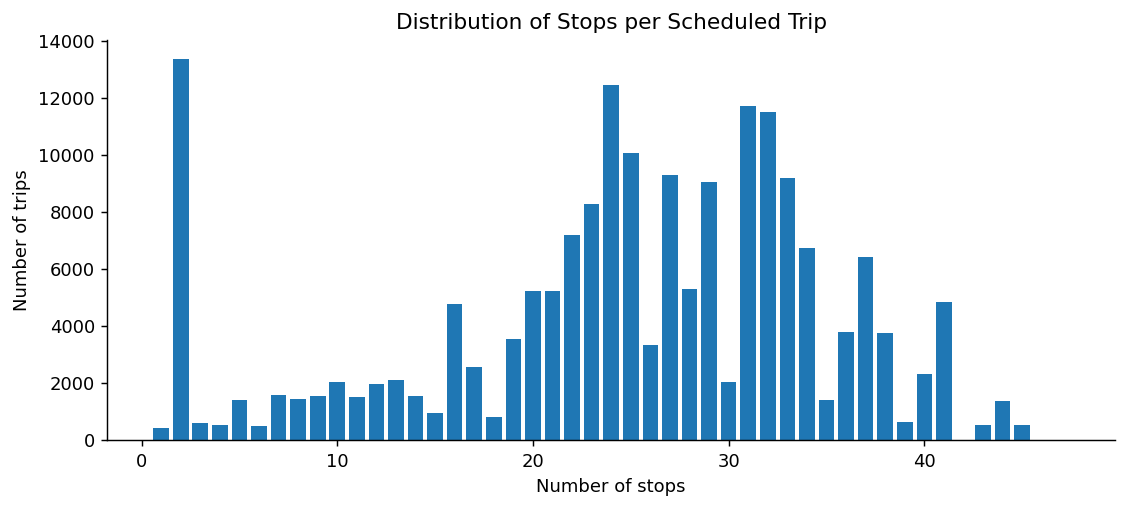

In [137]:
print(trips["n_stops"].value_counts().sort_index().head())

vc = trips["n_stops"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(vc.index, vc.values)
plt.xlabel("Number of stops")
plt.ylabel("Number of trips")
plt.title("Distribution of Stops per Scheduled Trip")
plt.show()

In [138]:
# TRIP ↔ STOP CATALOG INTEGRITY AUDIT
from collections import Counter

# Stop usage frequency
stop_freq = Counter()

for route in parsed_routes:
    for stop_id, _ in route:
        stop_freq[stop_id] += 1

freq_df = pd.DataFrame(stop_freq.items(), columns=["stop_id", "usage_count"])

# Join against stop catalog
audit = freq_df.merge(
    stops_clean[["stop_id", "stop_name", "lat", "lng"]], on="stop_id", how="left"
)

# Integrity flags
audit["missing_name"] = audit["stop_name"].isna()

audit["missing_coords"] = audit["lat"].isna() | audit["lng"].isna()

audit["invalid_coords"] = (
    (audit["lat"] < 18)
    | (audit["lat"] > 20)
    | (audit["lng"] < 72)
    | (audit["lng"] > 74)
)

print("TRIP ↔ STOP CATALOG INTEGRITY")

print(f"\nReferenced stop IDs      : {len(audit):,}")
print(f"Missing names            : {audit['missing_name'].sum():,}")
print(f"Missing coordinates      : {audit['missing_coords'].sum():,}")
print(f"Invalid coordinates      : {audit['invalid_coords'].sum():,}")

problematic = audit[
    audit["missing_name"] | audit["missing_coords"] | audit["invalid_coords"]
]

print(f"\nProblematic stop IDs     : {len(problematic):,}")
print(f"Total stop occurrences affected : " f"{problematic['usage_count'].sum():,}")

display(problematic.sort_values("usage_count", ascending=False).head(10))

TRIP ↔ STOP CATALOG INTEGRITY

Referenced stop IDs      : 3,945
Missing names            : 826
Missing coordinates      : 826
Invalid coordinates      : 9

Problematic stop IDs     : 835
Total stop occurrences affected : 1,449,497


,stop_id,usage_count,stop_name,lat,lng,missing_name,missing_coords,invalid_coords
2873,3593,13330,NaN,NaN,NaN,True,True,False
2915,3065,9871,NaN,NaN,NaN,True,True,False
2863,6237,9858,NaN,NaN,NaN,True,True,False
2860,4319,9858,NaN,NaN,NaN,True,True,False
2861,3611,9858,NaN,NaN,NaN,True,True,False
2862,8175,9858,NaN,NaN,NaN,True,True,False
2724,8176,9854,NaN,NaN,NaN,True,True,False
2726,4318,9854,NaN,NaN,NaN,True,True,False
2733,3953,8206,NaN,NaN,NaN,True,True,False
2875,3595,8150,NaN,NaN,NaN,True,True,False


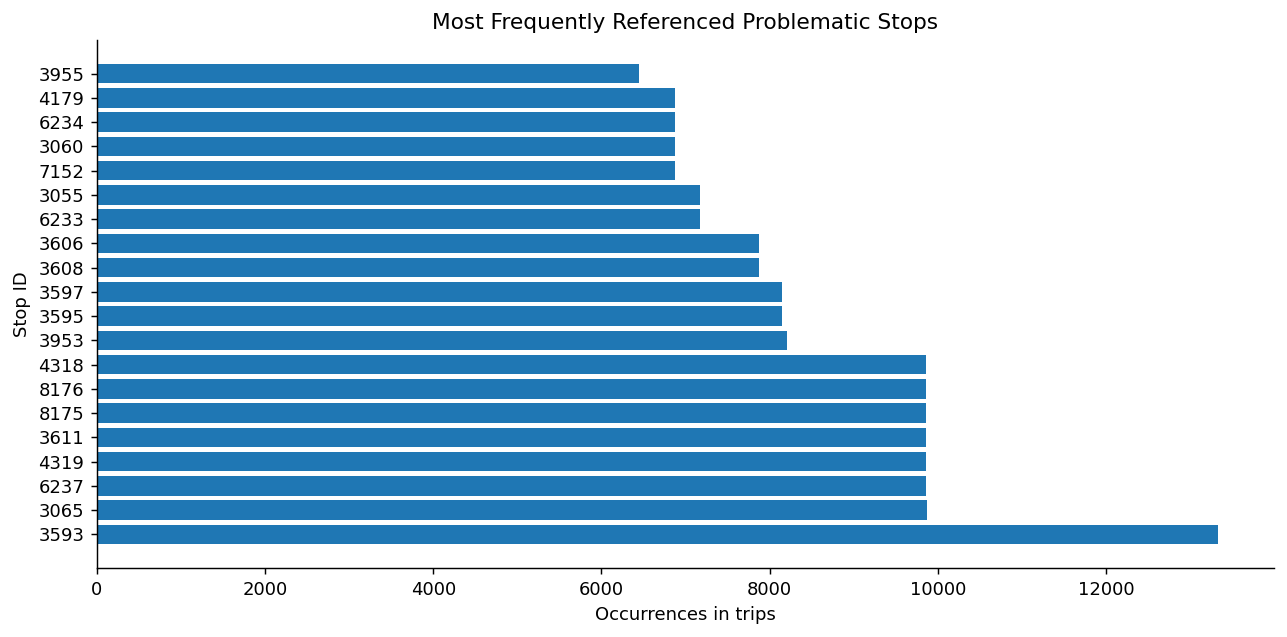

In [141]:
top_problematic = problematic.sort_values("usage_count", ascending=False).head(20)

plt.figure(figsize=(10, 5))

plt.barh(top_problematic["stop_id"].astype(str), top_problematic["usage_count"])

plt.xlabel("Occurrences in trips")
plt.ylabel("Stop ID")
plt.title("Most Frequently Referenced Problematic Stops")

plt.tight_layout()
plt.show()

### Findings

- 185,452 scheduled trips across 213 operating days.
- No duplicate trip IDs were observed.
- Routes reference 3,945 unique stop IDs.
- 863 unique route templates exist.
- Median route length is 26 stops.
- Route usage is highly concentrated, with a small subset of templates accounting for a large share of trips.
- 826 stop IDs referenced by trips are absent from the stop catalog.
- 125 route templates contain at least one missing stop.
- 45,907 trips (24.75%) are affected by missing stop references.

In [143]:
valid_stop_ids = set(stops_clean["stop_id"])

trip_stats = []

for _, row in trips.iterrows():
    route = parse_route(row["trip_route"])
    before = len(route)
    after = sum(stop_id in valid_stop_ids for stop_id, _ in route)
    trip_stats.append(
        {
            "trip_id": row["trip_id"],
            "stops_before": before,
            "stops_after": after,
            "stops_removed": before - after,
        }
    )

trip_impact = pd.DataFrame(trip_stats)

print("TRIP IMPACT ANALYSIS\n")
print("Trips affected:", (trip_impact["stops_removed"] > 0).sum())
print("Trips unchanged:", (trip_impact["stops_removed"] == 0).sum())
print("\nTrips reduced to <2 stops:", (trip_impact["stops_after"] < 2).sum())
print("Trips reduced to 0 stops:", (trip_impact["stops_after"] == 0).sum())
print("\nAverage stops removed:", round(trip_impact["stops_removed"].mean(), 2))

display(trip_impact["stops_removed"].describe())

TRIP IMPACT ANALYSIS

Trips affected: 45907
Trips unchanged: 139545

Trips reduced to <2 stops: 46231
Trips reduced to 0 stops: 45907

Average stops removed: 7.81


count    185452.000000
mean          7.810280
std          14.420365
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          47.000000
Name: stops_removed, dtype: float64

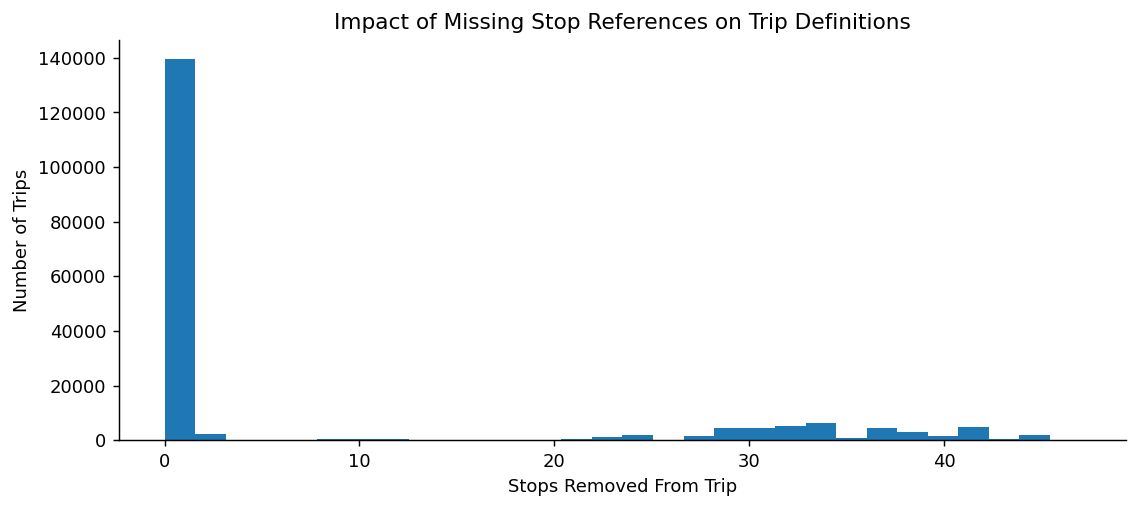

In [144]:
plt.figure(figsize=(10, 4))

plt.hist(trip_impact["stops_removed"], bins=30)

plt.xlabel("Stops Removed From Trip")
plt.ylabel("Number of Trips")
plt.title("Impact of Missing Stop References on Trip Definitions")

plt.show()

In [145]:
valid_stop_ids = set(
    stops_clean.loc[
        stops_clean["stop_name"].notna(),
        "stop_id",
    ]
)

cleaned_routes = []

for _, row in trips.iterrows():
    route = parse_route(row["trip_route"])
    route_clean = [(sid, t) for sid, t in route if sid in valid_stop_ids]
    cleaned_routes.append(route_clean)

trips_clean = trips.copy()

trips_clean["trip_route"] = [str(route) for route in cleaned_routes]

trips_clean["n_stops"] = [len(route) for route in cleaned_routes]

before = len(trips_clean)

trips_clean = trips_clean[trips_clean["n_stops"] >= 2].copy()

after = len(trips_clean)

print("Trips before:", before)
print("Trips after :", after)
print("Dropped     :", before - after)

OUT_TRIPS = PROCESSED / "trips_clean.csv"

trips_clean.drop(
    columns=["n_stops"],
    inplace=True,
)

trips_clean.to_csv(
    OUT_TRIPS,
    index=False,
)

print("Saved:", OUT_TRIPS)
print("Rows :", len(trips_clean))

Trips before: 185452
Trips after : 139221
Dropped     : 46231
Saved: ../data/processed/trips_clean.csv
Rows : 139221


In [149]:
trips_clean = pd.read_csv(PROCESSED / "trips_clean.csv")

parsed = trips_clean["trip_route"].apply(parse_route)

trip_stop_ids_clean = {sid for route in parsed for sid, _ in route}

remaining_missing = trip_stop_ids_clean - set(stops_clean["stop_id"])

print("Remaining missing stop IDs:", len(remaining_missing))
print("Trips remaining:", len(trips_clean))

Remaining missing stop IDs: 0
Trips remaining: 139221


In [3]:
trips_clean = pd.read_csv(PROCESSED / "trips_clean.csv")

print(trips_clean["trip_route"].iloc[0])

[(142, '19:30:00'), (152, '19:30:00'), (5301, '19:34:00'), (5302, '19:34:00'), (5303, '19:38:00'), (1021, '19:43:00'), (5148, '19:45:00'), (5305, '19:49:00'), (7219, '20:15:00'), (165, '20:50:00'), (172, '20:54:00'), (144, '21:00:00'), (171, '21:03:00'), (114, '21:07:00'), (4545, '21:12:00'), (130, '21:13:00'), (314, '21:14:00'), (326, '21:15:00'), (826, '21:19:00'), (6758, '21:21:00'), (156, '21:22:00'), (6232, '21:23:00'), (5931, '21:24:00'), (2929, '21:25:00'), (4909, '21:27:00'), (308, '21:31:00'), (622, '21:33:00')]


In [148]:
import ast

trip_stop_ids_clean = set()

for route_str in trips_clean["trip_route"]:
    route = ast.literal_eval(route_str)

    for stop_id, _ in route:
        trip_stop_ids_clean.add(stop_id)

print("Unique stop IDs after cleaning:", len(trip_stop_ids_clean))

remaining_missing = trip_stop_ids_clean - set(stops_clean["stop_id"])

print("Remaining missing stop IDs:", len(remaining_missing))

Unique stop IDs after cleaning: 3119
Remaining missing stop IDs: 0


In [17]:
import ast
import pandas as pd

bad_templates = set()
violations = []

for route_str in trips_clean["trip_route"]:

    route = ast.literal_eval(route_str)

    mins = []

    for _, t in route:
        h, m, s = map(int, t.split(":"))
        mins.append(h * 60 + m + s / 60)

    for i in range(len(mins) - 1):

        diff = mins[i] - mins[i + 1]

        if diff > 0:
            violations.append(diff)

    adjusted = [mins[0]]

    for x in mins[1:]:

        if x < adjusted[-1]:
            x += 1440

        adjusted.append(x)

    if not all(adjusted[i] <= adjusted[i + 1] for i in range(len(adjusted) - 1)):
        bad_templates.add(tuple(stop_id for stop_id, _ in route))

bad_template_trips = trips_clean[
    trips_clean["trip_route"].apply(
        lambda x: tuple(sid for sid, _ in ast.literal_eval(x)) in bad_templates
    )
]

v = pd.Series(violations)

print("SCHEDULE CONSISTENCY AUDIT\n")

print(f"Bad route templates : {len(bad_templates):,}")
print(f"Affected trips      : {len(bad_template_trips):,}")
print(
    f"Share of trips      : " f"{100 * len(bad_template_trips) / len(trips_clean):.2f}%"
)

print("\nViolation magnitude (minutes)")
print(v.describe())

SCHEDULE CONSISTENCY AUDIT

Bad route templates : 92
Affected trips      : 4,096
Share of trips      : 2.94%

Violation magnitude (minutes)
count    8197.000000
mean       13.992648
std        35.347311
min         0.266667
25%         2.000000
50%         8.000000
75%        17.000000
max      1438.000000
dtype: float64


In [20]:
examples = []

for route_str in trips_clean["trip_route"]:
    route = ast.literal_eval(route_str)
    mins = []

    for _, t in route:
        h, m, s = map(int, t.split(":"))
        mins.append(h * 60 + m)

    adjusted = [mins[0]]

    for x in mins[1:]:
        if x < adjusted[-1]:
            x += 1440

        adjusted.append(x)

    if not all(adjusted[i] <= adjusted[i + 1] for i in range(len(adjusted) - 1)):
        examples.append(route)

print("Sample problematic routes:")
for r in examples[:5]:
    print("\n---")
    print(r)

Sample problematic routes:

---
[(912, '16:30:00'), (836, '16:34:00'), (844, '16:37:00'), (11492, '16:39:00'), (841, '16:42:00'), (1740, '17:06:00'), (1178, '17:00:00'), (1011, '17:10:00'), (1012, '16:54:00'), (1947, '16:46:00'), (165, '17:43:00'), (172, '17:45:00'), (144, '17:52:00'), (171, '17:55:00'), (114, '17:58:00'), (130, '18:00:00'), (314, '18:02:00'), (326, '18:04:00'), (826, '18:05:00'), (156, '18:08:00'), (308, '18:13:00'), (622, '18:15:00')]

---
[(912, '17:00:00'), (836, '17:04:00'), (844, '17:07:00'), (11492, '17:09:00'), (841, '17:12:00'), (1740, '17:36:00'), (1178, '17:16:00'), (1012, '17:24:00'), (1011, '17:40:00'), (1947, '17:30:00'), (165, '18:13:00'), (172, '18:15:00'), (144, '18:22:00'), (171, '18:25:00'), (114, '18:28:00'), (130, '18:30:00'), (314, '18:32:00'), (326, '18:34:00'), (826, '18:35:00'), (156, '18:38:00'), (308, '18:43:00'), (622, '18:45:00')]

---
[(912, '19:30:00'), (836, '19:34:00'), (844, '19:37:00'), (11492, '19:39:00'), (841, '19:42:00'), (1740, '

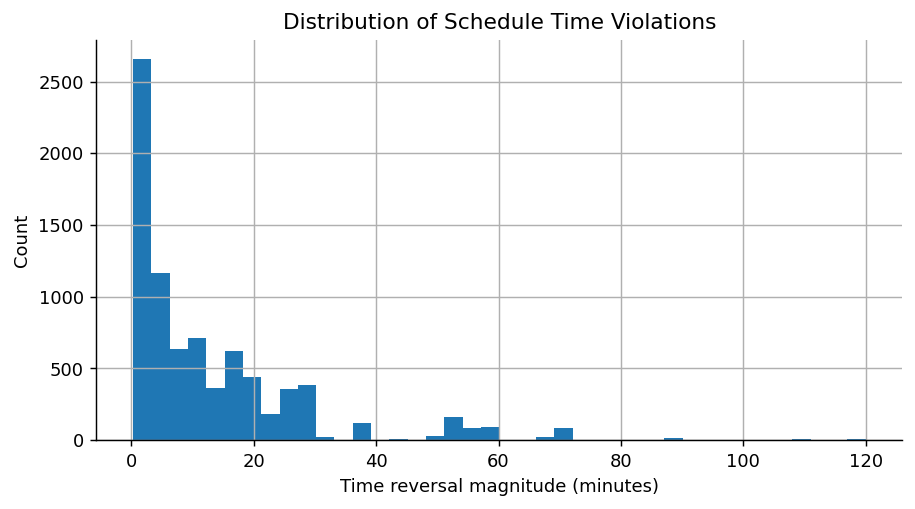

In [19]:
plt.figure(figsize=(8, 4))

pd.Series(violations).clip(upper=120).hist(bins=40)

plt.xlabel("Time reversal magnitude (minutes)")
plt.ylabel("Count")
plt.title("Distribution of Schedule Time Violations")
plt.show()

In [21]:
import ast

print("Rows before:", len(trips_clean))

trips_clean = trips_clean[
    ~trips_clean["trip_route"].apply(
        lambda x: tuple(sid for sid, _ in ast.literal_eval(x)) in bad_templates
    )
].copy()

print("Rows after :", len(trips_clean))
print("Dropped    :", len(bad_template_trips))

OUT_TRIPS = PROCESSED / "trips_clean.csv"

trips_clean.to_csv(
    OUT_TRIPS,
    index=False,
)

print("Saved:", OUT_TRIPS)

Rows before: 139221
Rows after : 135125
Dropped    : 4096
Saved: ../data/processed/trips_clean.csv


In [25]:
import ast

bad_remaining = 0

for route_str in trips_clean["trip_route"]:

    route = ast.literal_eval(route_str)

    mins = []

    for _, t in route:
        h, m, s = map(int, t.split(":"))
        mins.append(h * 60 + m)

    adjusted = [mins[0]]

    for x in mins[1:]:
        if x < adjusted[-1]:
            x += 1440
        adjusted.append(x)

    if not all(adjusted[i] <= adjusted[i + 1] for i in range(len(adjusted) - 1)):
        bad_remaining += 1

print("Remaining bad routes:", bad_remaining)
print(
    "Unique route templates: ",
    len(
        trips_clean["trip_route"]
        .apply(lambda x: tuple(sid for sid, _ in ast.literal_eval(x)))
        .unique()
    ),
)

Remaining bad routes: 0
Unique route templates:  641


### Findings

- 185,452 scheduled trips were present in the raw dataset.
- No duplicate trip IDs were observed.
- Routes referenced 3,945 unique stop IDs.
- 863 unique route templates were identified.
- Median route length was 26 stops.`
- 826 stop IDs referenced by trips were absent from the validated stop catalog.
- 9 stop records contained invalid coordinates and were repaired using manually validated coordinates.
- Problematic stop references accounted for 1,449,497 stop occurrences across scheduled routes.
- Removing unresolved stop references reduced the trip dataset from 185,452 to 139,221 trips.
- 46,231 trips (24.93%) became invalid (<2 remaining stops) and were removed.
- The resulting dataset contained 3,119 valid stop IDs with no unresolved stop references.
- Schedule consistency checks identified 92 route templates with non-monotonic stop times.
- These templates affected 4,096 trips (2.94% of the stop-cleaned dataset).
- Following review, the affected templates were excluded from further analysis.
- The final cleaned trip dataset contains 135,125 trips spanning 641 valid route templates.
- No remaining schedule-consistency violations were detected under the adopted validation rules.

In [3]:
import ast
import pandas as pd

trips = pd.read_csv("../data/processed/trips_clean.csv")


def parse_route(route_str):
    try:
        return ast.literal_eval(route_str)
    except Exception:
        return []


trips["parsed"] = trips["trip_route"].apply(parse_route)

trips["stop_seq"] = trips["parsed"].apply(lambda p: [int(sid) for sid, _ in p])

repeated = trips["stop_seq"].apply(lambda seq: len(seq) != len(set(seq)))

print(f"Trips with repeated stops: {repeated.sum():,}")
print(f"Total trips: {len(trips):,}")
print(f"Percent: {100 * repeated.mean():.4f}%")


Trips with repeated stops: 0
Total trips: 135,125
Percent: 0.0000%


In [5]:
import ast
import pandas as pd

trips = pd.read_csv("../data/processed/trips_clean.csv")

trips["trip_date"] = pd.to_datetime(trips["trip_date"])


def parse_route(route):
    try:
        parsed = ast.literal_eval(route)

        return [(int(stop_id), str(time_str)) for stop_id, time_str in parsed]

    except Exception:
        return []


parsed_routes = trips["trip_route"].apply(parse_route)

trips["n_stops"] = parsed_routes.apply(len)

trips["stop_sequence"] = parsed_routes.apply(
    lambda x: tuple(stop_id for stop_id, _ in x)
)

trip_stop_ids = {stop_id for route in parsed_routes for stop_id, _ in route}

print("TRIP SUMMARY —")
print(f"Unique trip_ids : {trips['trip_id'].nunique():,}")
print(f"Duplicate IDs   : {trips['trip_id'].duplicated().sum():,}")

print(
    f"Date range      : "
    f"{trips['trip_date'].min().date()} → "
    f"{trips['trip_date'].max().date()}"
)
print(f"Unique dates    : {trips['trip_date'].nunique():,}")

print("\nROUTE STRUCTURE —")
print(f"Trips parsed           : {len(parsed_routes):,}")
print(f"Unique stop IDs used   : {len(trip_stop_ids):,}")
print(f"Unique route templates : {trips['stop_sequence'].nunique():,}")

print("\nStops per trip:")
print(trips["n_stops"].describe())


TRIP SUMMARY —
Unique trip_ids : 135,125
Duplicate IDs   : 0
Date range      : 2025-12-08 → 2026-06-30
Unique dates    : 189

ROUTE STRUCTURE —
Trips parsed           : 135,125
Unique stop IDs used   : 3,107
Unique route templates : 641

Stops per trip:
count    135125.000000
mean         22.446949
std           9.687792
min           2.000000
25%          17.000000
50%          24.000000
75%          29.000000
max          40.000000
Name: n_stops, dtype: float64


In [13]:
template_map = {
    seq: idx for idx, seq in enumerate(trips["stop_sequence"].drop_duplicates())
}

trips["template_id"] = [template_map[seq] for seq in trips["stop_sequence"]]

def schedule_signature(route):
    return tuple(t for _, t in route)


trips["schedule_signature"] = parsed_routes.apply(schedule_signature)

schedule_variants = trips.groupby("template_id")["schedule_signature"].nunique()

print(schedule_variants.describe())

display(schedule_variants.sort_values(ascending=False).head(20))


count    641.000000
mean       7.374415
std       12.258552
min        1.000000
25%        1.000000
50%        2.000000
75%        7.000000
max       78.000000
Name: schedule_signature, dtype: float64


template_id
20     78
52     76
17     70
2      70
38     69
102    62
18     62
28     53
22     52
74     51
64     50
70     49
58     48
51     48
34     46
53     45
15     45
12     45
0      43
65     42
Name: schedule_signature, dtype: int64

In [9]:
trips["start_time"] = parsed_routes.apply(lambda r: r[0][1])

departure_variants = trips.groupby("template_id")["start_time"].nunique()

print(departure_variants.describe())

display(departure_variants.sort_values(ascending=False).head(20))


count    641.000000
mean       3.017161
std        3.407898
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max       29.000000
Name: start_time, dtype: float64


template_id
20     29
28     24
18     23
102    20
51     18
65     17
64     17
526    17
38     16
52     16
17     16
591    14
22     14
2      14
4      13
50     13
77     12
563    12
54     12
53     12
Name: start_time, dtype: int64

In [10]:
monthly_counts = trips.groupby(trips["trip_date"].dt.to_period("M")).size()

print(monthly_counts)


trip_date
2025-12    17160
2026-01    21943
2026-02    22654
2026-03    23808
2026-04    17203
2026-05    15746
2026-06    16611
Freq: M, dtype: int64


In [11]:
template_months = trips.groupby("template_id")["trip_date"].apply(
    lambda x: x.dt.to_period("M").nunique()
)

print(template_months.describe())

display(template_months.value_counts().sort_index())


count    641.000000
mean       4.000000
std        1.982738
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: trip_date, dtype: float64


trip_date
1    101
2     50
3     63
4    256
5     20
6      7
7    144
Name: count, dtype: int64

In [12]:
trips["month"] = trips["trip_date"].dt.to_period("M")

monthly_schedule_variants = trips.groupby(["template_id", "month"])[
    "schedule_signature"
].nunique()

print(monthly_schedule_variants.describe())

display(monthly_schedule_variants.value_counts().sort_index())


count    2564.000000
mean        4.249610
std         5.488833
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        49.000000
Name: schedule_signature, dtype: float64


schedule_signature
1     1155
2      234
3      239
4      155
5      169
6      116
7      100
8       63
9       53
10      42
11      29
12      30
13      21
14      20
15       9
16      20
17      17
18      18
19       2
20      11
21       6
22       1
23       8
24       6
25       5
26       5
27       4
28       8
29       3
30       1
31       2
32       3
35       1
42       1
44       3
46       2
48       1
49       1
Name: count, dtype: int64

Templates with >=2 months: 540
Stable timetable set     : 275
Changed timetable set    : 265
Stable % 50.93


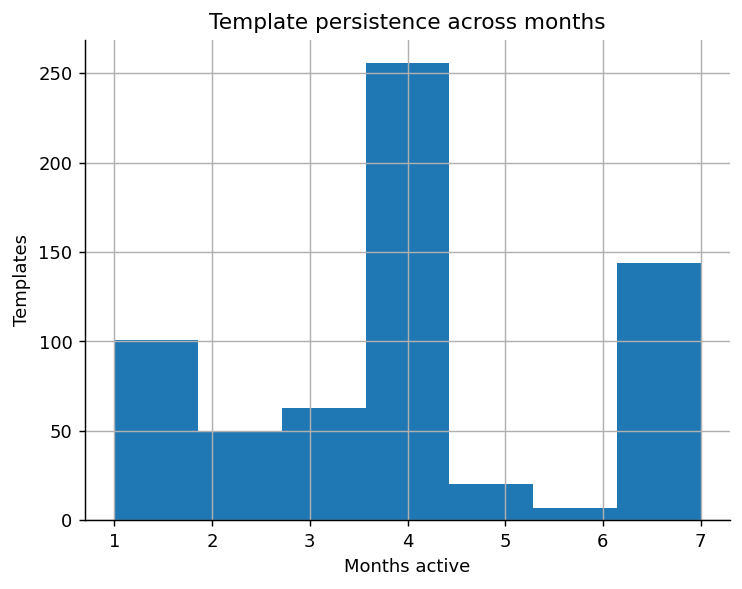

In [14]:
from collections import defaultdict
import matplotlib.pyplot as plt

trips["month"] = trips["trip_date"].dt.to_period("M")

template_month_schedules = trips.groupby(["template_id", "month"])[
    "schedule_signature"
].apply(set)

stable = 0
changed = 0

for template_id, grp in template_month_schedules.groupby(level=0):
    month_sets = list(grp.values)

    if len(month_sets) < 2:
        continue

    first = month_sets[0]

    if all(s == first for s in month_sets[1:]):
        stable += 1
    else:
        changed += 1

print("Templates with >=2 months:", stable + changed)
print("Stable timetable set     :", stable)
print("Changed timetable set    :", changed)

print("Stable %", round(100 * stable / (stable + changed), 2))


template_months.hist(bins=7)

plt.xlabel("Months active")
plt.ylabel("Templates")
plt.title("Template persistence across months")
plt.show()

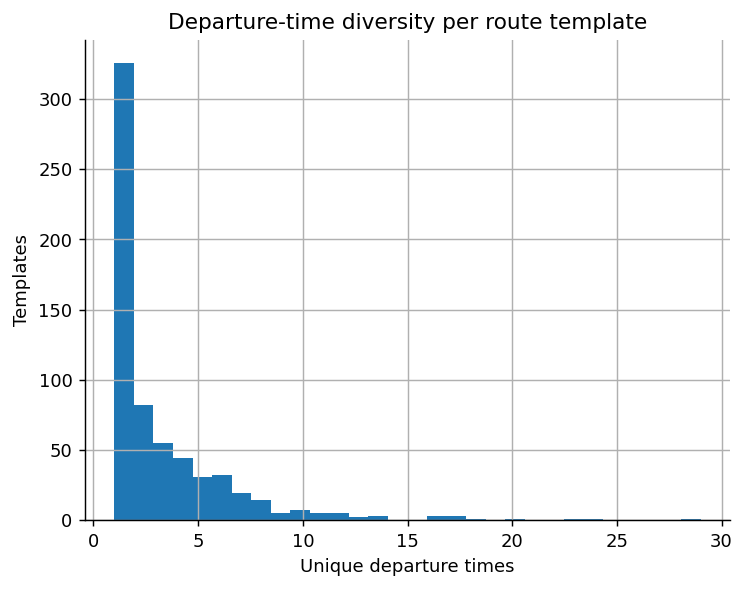

In [15]:
departure_variants.hist(bins=30)

plt.xlabel("Unique departure times")
plt.ylabel("Templates")
plt.title("Departure-time diversity per route template")
plt.show()

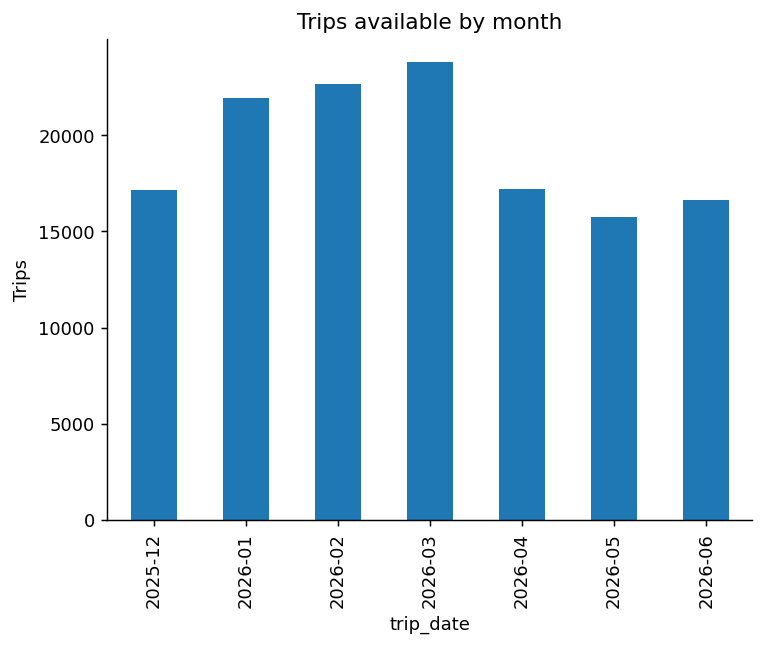

In [16]:
monthly_counts.plot(kind="bar")

plt.ylabel("Trips")
plt.title("Trips available by month")
plt.show()

In [17]:
from itertools import combinations
import numpy as np

template_month_schedules = trips.groupby(["template_id", "month"])[
    "schedule_signature"
].apply(set)

scores = []

for template_id, grp in template_month_schedules.groupby(level=0):
    month_sets = list(grp.values)

    if len(month_sets) < 2:
        continue

    for a, b in combinations(month_sets, 2):
        j = len(a & b) / len(a | b)

        scores.append(j)

scores = pd.Series(scores)

print(scores.describe())


count    5104.000000
mean        0.525363
std         0.444082
min         0.000000
25%         0.025000
50%         0.500000
75%         1.000000
max         1.000000
dtype: float64


In [18]:
template_month_counts = (
    trips.groupby(["template_id", "month"]).size().unstack(fill_value=0)
)

template_month_counts.head()


month,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
template_id,,,,,,,
0,101,124,134,134,154,140,154
1,26,31,4,0,0,0,0
2,192,234,239,254,286,260,286
3,95,126,110,118,132,120,132
4,53,75,72,79,87,80,88


In [19]:
cv = template_month_counts.std(axis=1) / template_month_counts.mean(axis=1)

print(cv.describe())


count    641.000000
mean       1.151482
std        0.807909
min        0.042680
25%        0.827182
50%        0.946434
75%        1.557776
max        2.645751
dtype: float64


### Schedule Stability Assessment

Because the available trip schedule archive spans only December 2025–June 2026 while GPS observations span September 2021–October 2022, an additional schedule stability analysis was performed.

Findings:

- 641 valid route templates were identified.
- 144 templates were present in all seven observed months.
- Route-template geometry appeared relatively stable across months.
- Timetable stability was substantially lower.
- Pairwise month-to-month schedule-set similarity had:
  - Mean Jaccard similarity = 0.525
  - Median Jaccard similarity = 0.500
- Monthly service frequency also varied materially:
  - Median coefficient of variation = 0.95
  - Mean coefficient of variation = 1.15
- The available schedule archive is suitable for deriving route structures and representative stop sequences. However, it cannot be assumed that service frequencies or departure schedules remained unchanged between 2021–2022 and 2025–2026.

In [21]:
_ROUTE_PAIR_RE = re.compile(r"(\d+)\s*,\s*(\d{6}|\d{2}:\d{2}:\d{2})")


def _normalize_time_str(t: str) -> str:
    t = str(t).strip()
    if ":" in t:
        parts = t.split(":")
        if len(parts) == 3:
            hh, mm, ss = parts
            return f"{int(hh):02d}:{int(mm):02d}:{int(ss):02d}"
    if len(t) == 6 and t.isdigit():
        return f"{t[0:2]}:{t[2:4]}:{t[4:6]}"
    raise ValueError(f"Unrecognized time format: {t!r}")


def _time_str_to_minutes(t: str) -> float:
    hh, mm, ss = map(int, _normalize_time_str(t).split(":"))
    return hh * 60.0 + mm + ss / 60.0

def _parse_trip_route(route_str) -> list[tuple[int, float]]:
    """
    Parse trip_route string into a list of (stop_id, arrival_min) pairs.
    Handles both the canonical list-of-tuples format and the regex fallback.
    Returns an empty list on any parse failure.
    """
    if pd.isna(route_str):
        return []
    s = str(route_str).strip()
    if not s:
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = ast.literal_eval(s)
            out: list[tuple[int, float]] = []
            for item in parsed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    sid = int(item[0])
                    arrival_min = _time_str_to_minutes(item[1])
                    out.append((sid, arrival_min))
            return out
        except Exception:
            pass

    out = []
    for sid_str, t_str in _ROUTE_PAIR_RE.findall(s):
        out.append((int(sid_str), _time_str_to_minutes(t_str)))
    return out


def _build_trip_stop_schedule(trips_path: Path) -> pd.DataFrame:
    """
    Build a flat (trip_id, stop_id, scheduled_arrival_min) table from
    trips_clean.csv.

    Each row in trips_clean.csv contains trip_route, an ordered list of
    (stop_id, HH:MM:SS) pairs representing the exact operational schedule for
    that trip.  This function explodes those pairs into one row per
    (trip_id, stop_id), keeping only the *first* occurrence of each stop_id
    within a trip (consistent with how 05_route_inference handles duplicates).

    Returns
    -------
    pd.DataFrame with columns:
        trip_id                 int
        stop_id                 int
        scheduled_arrival_min   float   — minutes from midnight (local IST)
    """
    trips_df = pd.read_csv(trips_path)
    trips_df = trips_df.rename(
        columns={
            "tripid": "trip_id",
            "triproute": "trip_route",
            "tripdate": "trip_date",
        }
    )
    trips_df["trip_id"] = trips_df["trip_id"].astype(int)

    rows: list[dict] = []
    for _, row in trips_df.iterrows():
        trip_id = int(row["trip_id"])
        parsed = _parse_trip_route(row["trip_route"])
        seen_stops: set[int] = set()
        for stop_id, arrival_min in parsed:
            if stop_id in seen_stops:
                continue  # keep first occurrence only
            seen_stops.add(stop_id)
            rows.append(
                {
                    "trip_id": trip_id,
                    "stop_id": stop_id,
                    "scheduled_arrival_min": arrival_min,
                }
            )

    schedule_df = pd.DataFrame(rows)
    if schedule_df.empty:
        return schedule_df

    schedule_df["trip_id"] = schedule_df["trip_id"].astype(int)
    schedule_df["stop_id"] = schedule_df["stop_id"].astype(int)
    schedule_df["scheduled_arrival_min"] = schedule_df["scheduled_arrival_min"].astype(
        float
    )
    return schedule_df

trip_stop_schedule_df = _build_trip_stop_schedule(TRIPS_FILE)

print(len(trip_stop_schedule_df))

print(trip_stop_schedule_df.groupby(["trip_id", "stop_id"]).size().gt(1).sum())

4581865
0


In [22]:
trip_stop_schedule_df["scheduled_arrival_min"].describe()


count    4.581865e+06
mean     8.271696e+02
std      3.146588e+02
min      0.000000e+00
25%      5.250000e+02
50%      6.900000e+02
75%      1.129000e+03
max      1.439983e+03
Name: scheduled_arrival_min, dtype: float64